In [29]:
#import all necessary libs
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
import os
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#load data
df = pd.read_csv('~/Documents/TITAN/data/processed/train_cleaned.csv')

#separate the 'target' feature from the rest of the data
X = df.drop('target', axis=1)
y = df['target']

#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

[0]	validation_0-logloss:0.64309
[1]	validation_0-logloss:0.60010
[2]	validation_0-logloss:0.56183
[3]	validation_0-logloss:0.52745
[4]	validation_0-logloss:0.49538
[5]	validation_0-logloss:0.46552
[6]	validation_0-logloss:0.43780
[7]	validation_0-logloss:0.41196
[8]	validation_0-logloss:0.38864
[9]	validation_0-logloss:0.36670
[10]	validation_0-logloss:0.34638
[11]	validation_0-logloss:0.32730
[12]	validation_0-logloss:0.30932
[13]	validation_0-logloss:0.29244
[14]	validation_0-logloss:0.27678
[15]	validation_0-logloss:0.26220
[16]	validation_0-logloss:0.24855
[17]	validation_0-logloss:0.23574
[18]	validation_0-logloss:0.22380
[19]	validation_0-logloss:0.21234
[20]	validation_0-logloss:0.20135
[21]	validation_0-logloss:0.19131
[22]	validation_0-logloss:0.18182
[23]	validation_0-logloss:0.17279
[24]	validation_0-logloss:0.16434
[25]	validation_0-logloss:0.15643
[26]	validation_0-logloss:0.14894
[27]	validation_0-logloss:0.14187
[28]	validation_0-logloss:0.13517
[29]	validation_0-loglos

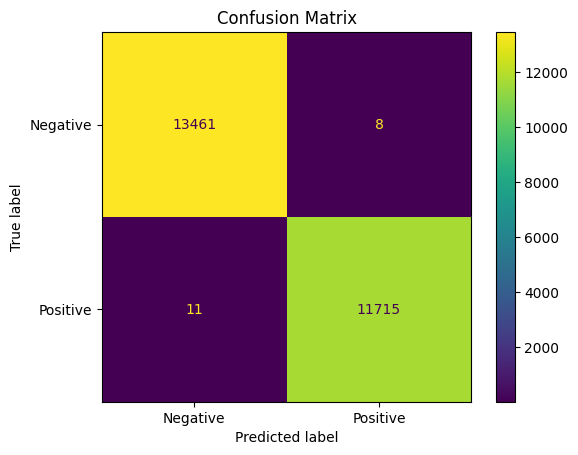

In [ ]:
xgb_model = XGBClassifier(
                            n_estimators=1000,              #number of trees=1000
                            learning_rate=0.05,             #step size=0.05
                            max_depth=6,                    #max depth per tree=6
                            subsample=0.8,                  #only check 80% of the data entries
                            colsample_bytree=0.8,           #only check 80% of the features
                            early_stopping_rounds=10        #if the model doesn't improve by 10 rounds in a row, end training and save best version
                          )

scaler = StandardScaler()
scaler.fit(X_train)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
y_pred=xgb_model.predict(X_test)
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,display_labels=["Negative","Positive"])

print(f"best iteration: {xgb_model.best_iteration}")
print(f"best score: {xgb_model.best_score}")
print(f"classification score: {classification_report(y_test, y_pred)}")
print(f"confusion matrix: {conf_matrix}")

disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#model showed extremely good results, test to see if it's cheating by listing most important features
importances = xgb_model.feature_importances_
feature_names = X_train.columns

#sort to see the top 10 most influential features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

print(feature_importance_df)

                Feature  Importance
56        service_ecr_i    0.193916
65         service_http    0.152800
1             src_bytes    0.121326
2             dst_bytes    0.092793
106       service_urp_i    0.042124
19                count    0.039989
25        same_srv_rate    0.038002
6                   hot    0.035580
38   protocol_type_icmp    0.022797
90      service_private    0.019097


In [32]:
if not os.path.exists('models'):
    os.makedirs('../models')

#save the model
joblib.dump(xgb_model, '../models/titan_xgb_v1.pkl')
#save the scaler
joblib.dump(scaler, '../models/scaler_v1.pkl')

['../models/scaler_v1.pkl']